# 📊 EDA — The Returning Soldier Effect
## Exploratory Data Analysis of Historical Birth Sex Ratios

This notebook explores the HMD births dataset across 13 countries (1806–2024).
We follow a structured EDA process:
1. Data Overview
2. Duplicate Check  
3. Data Type Validation
4. Descriptive Statistics
5. Categorical Column Check
6. Time Series Visualisation

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
PROJECT_ROOT = Path.cwd().parent
BIRTHS_DIR = PROJECT_ROOT/"data"/"raw"/"births"
CASUALTIES_DIR = PROJECT_ROOT/"data"/"raw"/"casualties"
POPULATION_DIR = PROJECT_ROOT/"data"/"raw"/"population"
BIRTHS_DIR.mkdir(parents=True, exist_ok=True)
CASUALTIES_DIR.mkdir(parents=True, exist_ok=True)
POPULATION_DIR.mkdir(parents=True, exist_ok=True)

Loading HMD births

In [28]:
all_dfs = []

for file in BIRTHS_DIR.glob("*.txt"):
    df = pd.read_csv(file)
    all_dfs.append(df)

hmd_births = pd.concat(all_dfs, ignore_index=True)
print(hmd_births.shape)
hmd_births.head()

(3674, 12)


,PopName,Area,Sex,Year,YearReg,RefCode,Access,Births,NoteCode1,NoteCode2,NoteCode3,LDB
0,AUS,1,f,1860,1860,32,O,23262,10,8,.,1
1,AUS,1,m,1860,1860,32,O,24464,10,8,.,1
2,AUS,1,f,1861,1861,32,O,23806,10,8,.,1
3,AUS,1,m,1861,1861,32,O,25102,10,8,.,1
4,AUS,1,f,1862,1862,32,O,24896,10,8,.,1


## EDA Step 1 — Data Overview

In [29]:
hmd_births.info()

<class 'pandas.DataFrame'>
RangeIndex: 3674 entries, 0 to 3673
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   PopName    3674 non-null   str   
 1   Area       3674 non-null   int64 
 2   Sex        3674 non-null   str   
 3   Year       3674 non-null   int64 
 4   YearReg    3674 non-null   int64 
 5   RefCode    3674 non-null   int64 
 6   Access     3674 non-null   str   
 7   Births     3674 non-null   int64 
 8   NoteCode1  3674 non-null   object
 9   NoteCode2  3674 non-null   str   
 10  NoteCode3  3674 non-null   str   
 11  LDB        3674 non-null   int64 
dtypes: int64(6), object(1), str(5)
memory usage: 373.0+ KB


## EDA Step 2 — Duplicate Check

In [30]:
hmd_births.duplicated().sum()

np.int64(0)

In [31]:
hmd_births.duplicated(subset=["PopName", "Year", "Sex"]).sum()

np.int64(286)

In [32]:
mask = hmd_births.duplicated(subset=["PopName", "Year", "Sex"], keep=False)
hmd_births[mask].sort_values(["PopName", "Year", "Sex"]).head(20)

,PopName,Area,Sex,Year,YearReg,RefCode,Access,Births,NoteCode1,NoteCode2,NoteCode3,LDB
742,BEL,10,f,1886,1886,3,O,85773,20,.,.,1
743,BEL,130,f,1886,1886,38,O,630,34,.,.,0
744,BEL,130,m,1886,1886,38,O,860,34,.,.,0
745,BEL,10,m,1886,1886,3,O,89318,20,.,.,1
746,BEL,130,f,1887,1887,38,O,628,34,.,.,0
747,BEL,10,f,1887,1887,3,O,85645,20,.,.,1
748,BEL,10,m,1887,1887,3,O,89821,20,.,.,1
749,BEL,130,m,1887,1887,38,O,848,34,.,.,0
750,BEL,10,f,1888,1888,3,O,86303,20,.,.,1
751,BEL,130,f,1888,1888,38,O,588,34,.,.,0


In [33]:
hmd_births_clean = hmd_births[hmd_births["LDB"] == 1]

## EDA Step 3 — Data Type Validation

In [34]:
hmd_births_clean.duplicated(subset=["PopName", "Year", "Sex"]).sum()
hmd_births_clean.info()

<class 'pandas.DataFrame'>
Index: 3360 entries, 0 to 3673
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   PopName    3360 non-null   str   
 1   Area       3360 non-null   int64 
 2   Sex        3360 non-null   str   
 3   Year       3360 non-null   int64 
 4   YearReg    3360 non-null   int64 
 5   RefCode    3360 non-null   int64 
 6   Access     3360 non-null   str   
 7   Births     3360 non-null   int64 
 8   NoteCode1  3360 non-null   object
 9   NoteCode2  3360 non-null   str   
 10  NoteCode3  3360 non-null   str   
 11  LDB        3360 non-null   int64 
dtypes: int64(6), object(1), str(5)
memory usage: 369.6+ KB


## EDA Step 4 — Descriptive Statistics

In [35]:
hmd_births_clean.describe()

,Area,Year,YearReg,RefCode,Births,LDB
count,3360.000000,3360.000000,3360.000000,3360.000000,3.360000e+03,3360.0
mean,16.083929,1947.933929,1947.933929,35.547024,3.900841e+05,1.0
std,27.288270,50.764560,50.764560,49.709644,4.374348e+05,0.0
min,1.000000,1806.000000,1806.000000,1.000000,2.326200e+04,1.0
25%,1.000000,1910.000000,1910.000000,5.000000,7.996825e+04,1.0
50%,1.000000,1957.000000,1957.000000,13.000000,3.016210e+05,1.0
75%,20.000000,1990.000000,1990.000000,46.000000,4.716232e+05,1.0
max,90.000000,2024.000000,2024.000000,320.000000,2.208071e+06,1.0


In [36]:
hmd_births_clean[hmd_births_clean["Year"] < 1816]["PopName"].unique()

<ArrowStringArray>
['FRATNP']
Length: 1, dtype: str

In [37]:
(hmd_births_clean["Year"] < 1816).sum()

np.int64(20)

French birth records prior to 1816 are included from Napoleonic-era civil registration. These 20 rows predate our earliest war (Franco-Prussian, 1870) and serve only as extended baseline data.

## EDA Step 5 — Categorical Column Check

In [38]:
print(hmd_births_clean["Sex"].value_counts())
print(hmd_births_clean["PopName"].value_counts())

Sex
f    1680
m    1680
Name: count, dtype: int64
PopName
FRATNP     436
BEL        370
GBRTENW    364
AUS        324
ITA        324
AUT        306
JPN        292
CAN        206
USA        184
DEUTE      150
DEUTW      150
HUN        142
RUS        112
Name: count, dtype: int64


In [40]:
hmd_births_bnw = hmd_births_clean[hmd_births_clean["PopName"]== "GBRTENW"]

## EDA Step 6 — Time Series Visualisation

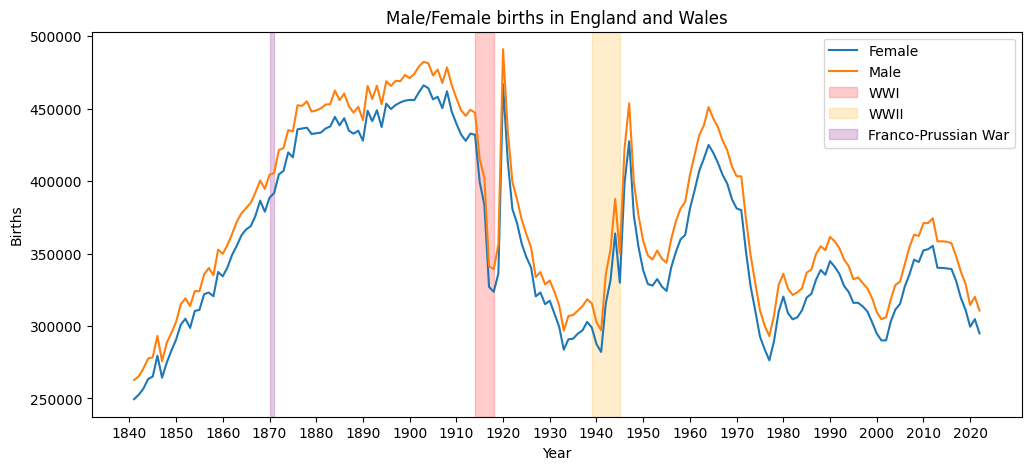

In [49]:
fig, ax = plt.subplots(figsize=(12,5))
sex_labels = {'f': 'Female', 'm': 'Male'}
for sex, group in hmd_births_bnw.groupby("Sex"):
    ax.plot(group["Year"], group["Births"], label=sex_labels[sex])
    
ax.set_title("Male/Female births in England and Wales")
ax.set_xlabel("Year")
ax.set_ylabel("Births")
ax.set_xticks(range(1840, 2030, 10))
ax.axvspan(1914, 1918, alpha=0.2, color='red', label='WWI')
ax.axvspan(1939, 1945, alpha=0.2, color='orange', label='WWII')
ax.axvspan(1870, 1871, alpha=0.2, color='purple', label='Franco-Prussian War')
ax.legend()
plt.show()

In [50]:
srb_uk = hmd_births_bnw.pivot(index="Year", columns="Sex", values="Births")
print(srb_uk.head())

Sex        f       m
Year                
1841  249444  262714
1842  252535  265204
1843  256748  270577
1844  263327  277436
1845  265103  278418


In [59]:
srb_uk["SRB"] = srb_uk["m"]/srb_uk['f']
srb_uk.head()

Sex,f,m,SRB
Year,,,
1841,249444,262714,1.053198
1842,252535,265204,1.050167
1843,256748,270577,1.053862
1844,263327,277436,1.053580
1845,265103,278418,1.050226


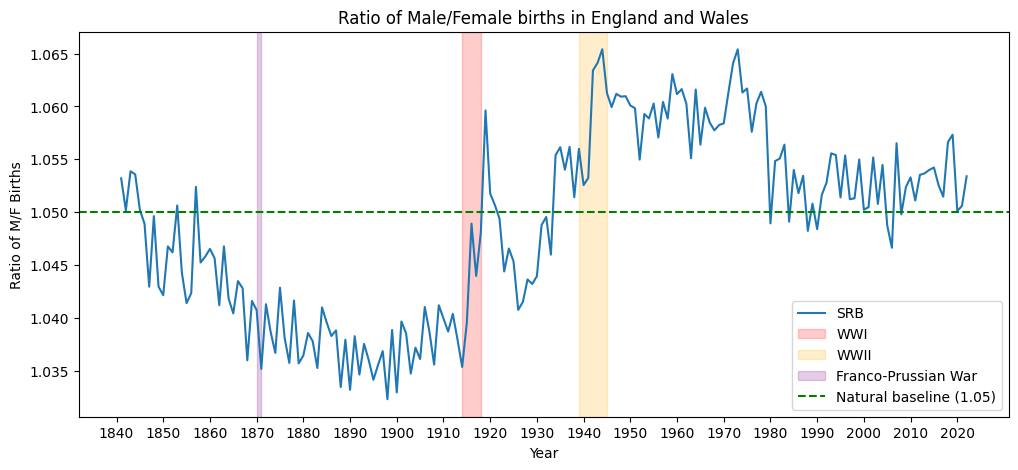

In [70]:
fig, ax = plt.subplots(figsize=(12,5))
#sex_labels = {'f': 'Female', 'm': 'Male'}
ax.plot(srb_uk.index, srb_uk["SRB"], label="SRB")  
ax.set_title("Ratio of Male/Female births in England and Wales")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio of M/F Births")
ax.set_xticks(range(1840, 2030, 10))
ax.axvspan(1914, 1918, alpha=0.2, color='red', label='WWI')
ax.axvspan(1939, 1945, alpha=0.2, color='orange', label='WWII')
ax.axvspan(1870, 1871, alpha=0.2, color='purple', label='Franco-Prussian War')
ax.axhline(1.05, color='green', linestyle='--', label='Natural baseline (1.05)')
ax.legend()
plt.show()

Plotting the Sex at birth ratio of females to males

In [62]:
srb_uk["f_to_m"] = srb_uk["f"] / srb_uk["m"]

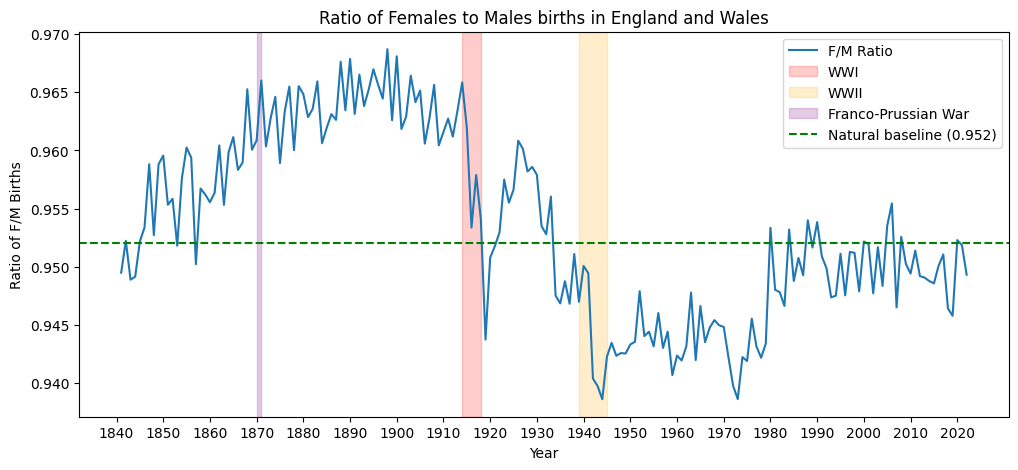

In [76]:
fig, ax = plt.subplots(figsize=(12,5))
#sex_labels = {'f': 'Female', 'm': 'Male'}
ax.plot(srb_uk.index, srb_uk["f_to_m"], label="F/M Ratio")  
ax.set_title("Ratio of Females to Males births in England and Wales")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio of F/M Births")
ax.set_xticks(range(1840, 2030, 10))
ax.axvspan(1914, 1918, alpha=0.2, color='red', label='WWI')
ax.axvspan(1939, 1945, alpha=0.2, color='orange', label='WWII')
ax.axvspan(1870, 1871, alpha=0.2, color='purple', label='Franco-Prussian War')
ax.axhline(0.952, color='green', linestyle='--', label='Natural baseline (0.952)')
ax.legend()
plt.show()

In [ ]:
def calculate_srb(df, country_code):
    df = df[df["PopName"]== country_code]
    srb_country = df.pivot(index="Year", columns="Sex", values="Births")
    srb_country["SRB"] = srb_country["m"]/srb_country['f']
    return srb_country

In [65]:
calculate_srb(hmd_births_clean, "GBRTENW")

Sex,f,m,SRB
Year,,,
1841,249444,262714,1.053198
1842,252535,265204,1.050167
1843,256748,270577,1.053862
1844,263327,277436,1.053580
1845,265103,278418,1.050226
...,...,...,...
2018,319419,337506,1.056625
2019,311263,329107,1.057328
2020,299466,314470,1.050103


In [74]:
country_codes = hmd_births_clean["PopName"].unique()
country_codes

<ArrowStringArray>
[    'AUS',     'AUT',     'BEL',     'CAN',   'DEUTE',   'DEUTW',  'FRATNP',
 'GBRTENW',     'HUN',     'ITA',     'JPN',     'RUS',     'USA']
Length: 13, dtype: str

AUS


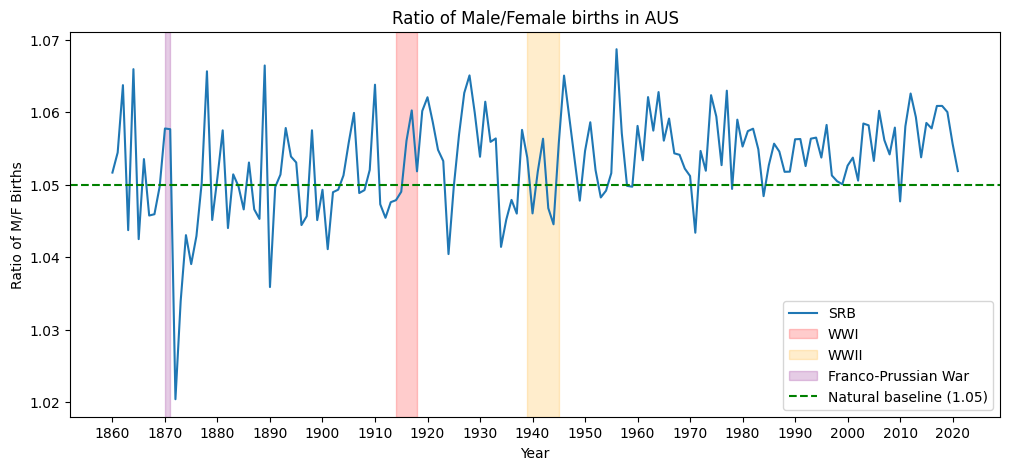

AUT


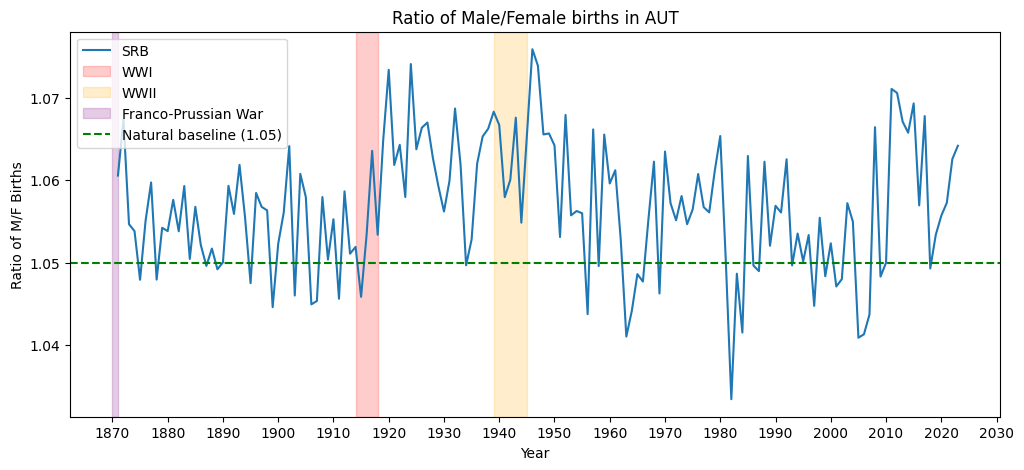

BEL


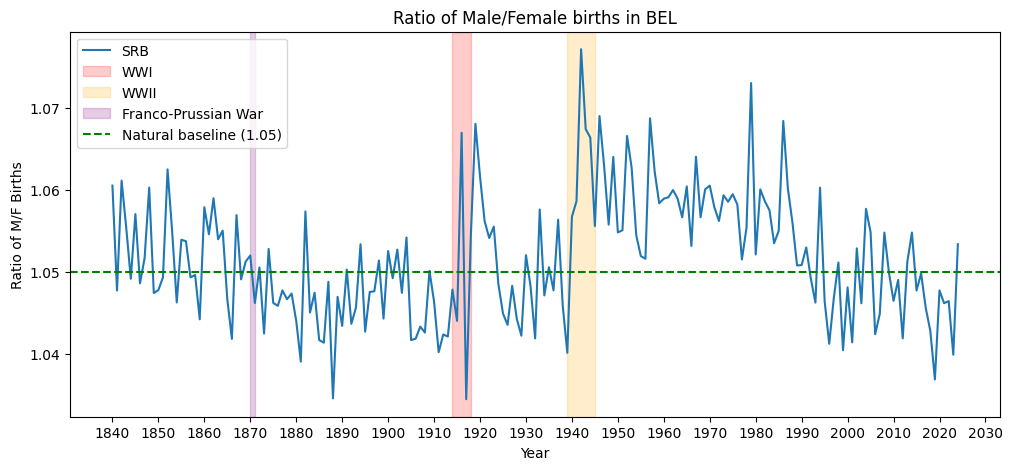

CAN


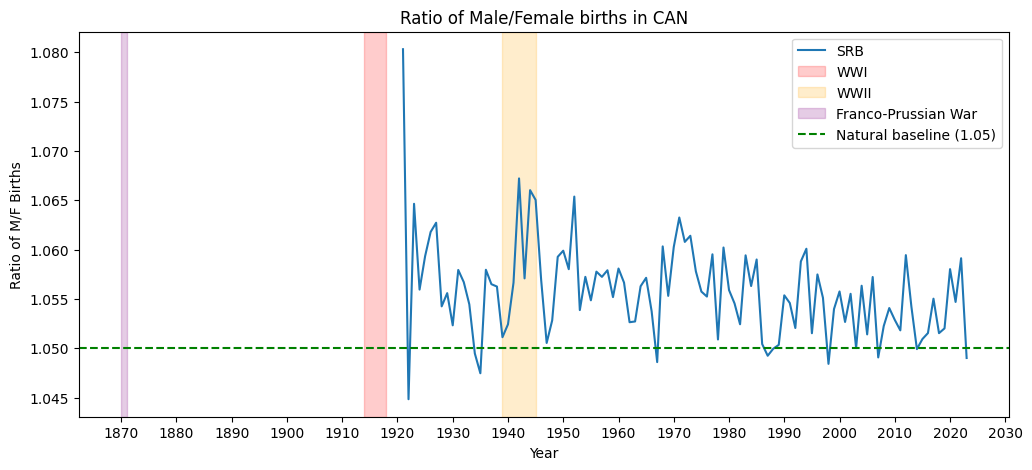

DEUTE


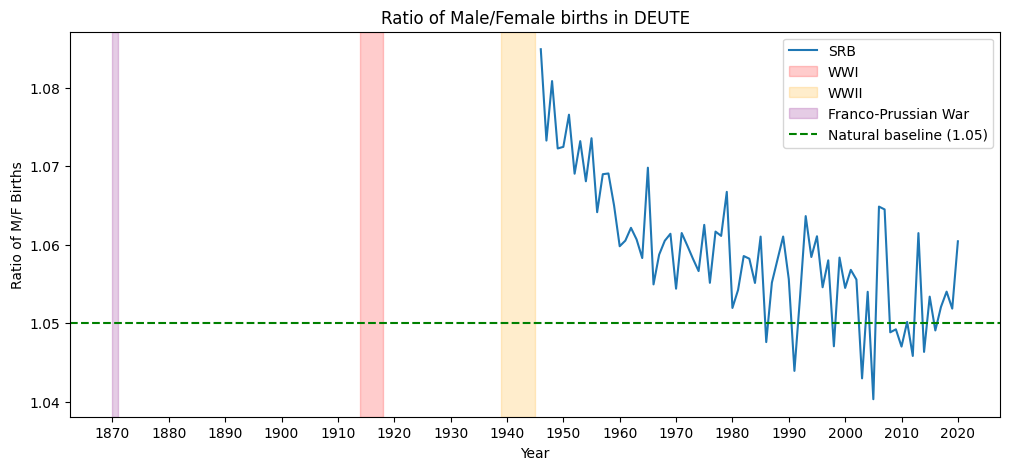

DEUTW


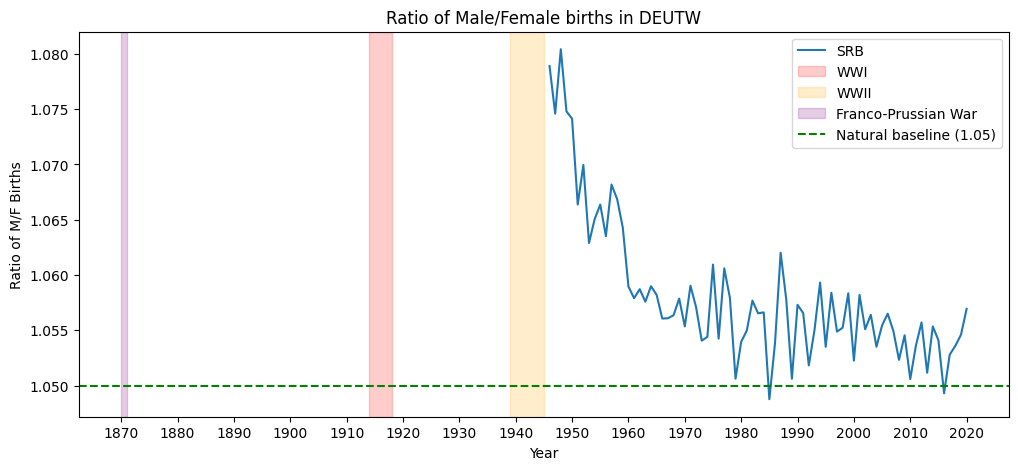

FRATNP


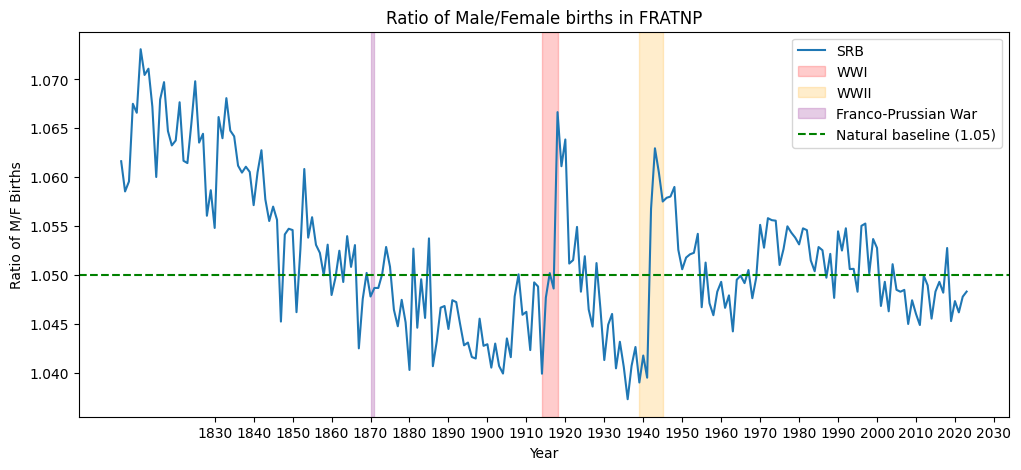

GBRTENW


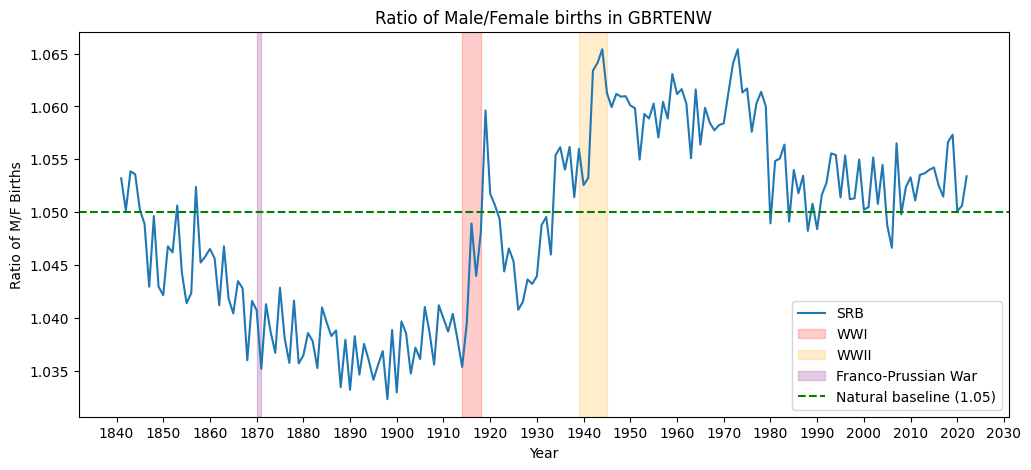

HUN


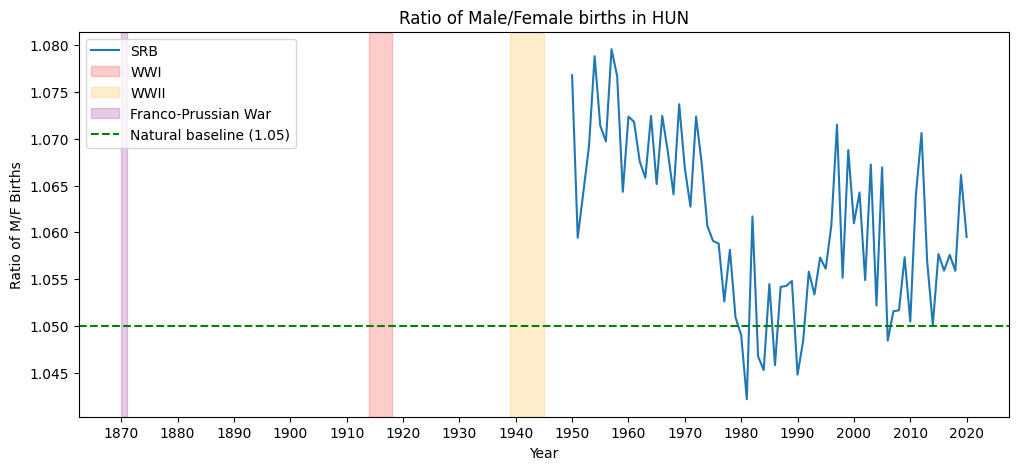

ITA


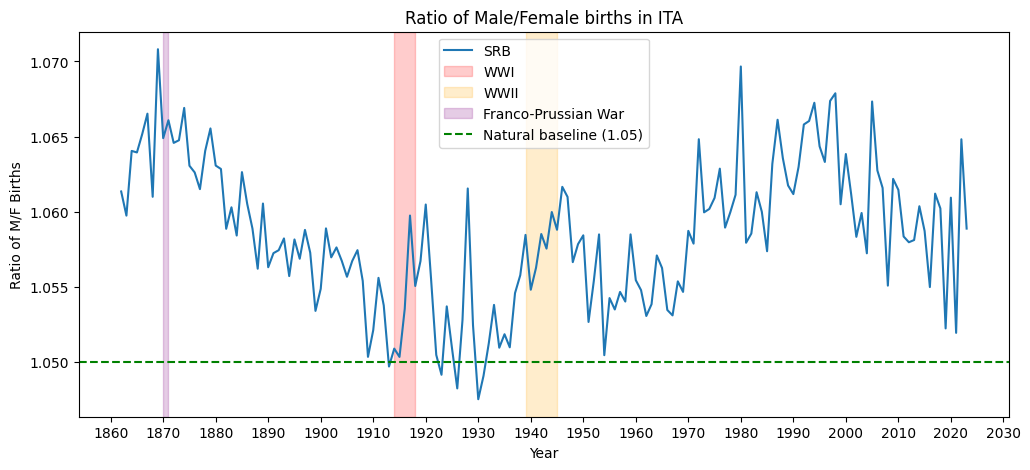

JPN


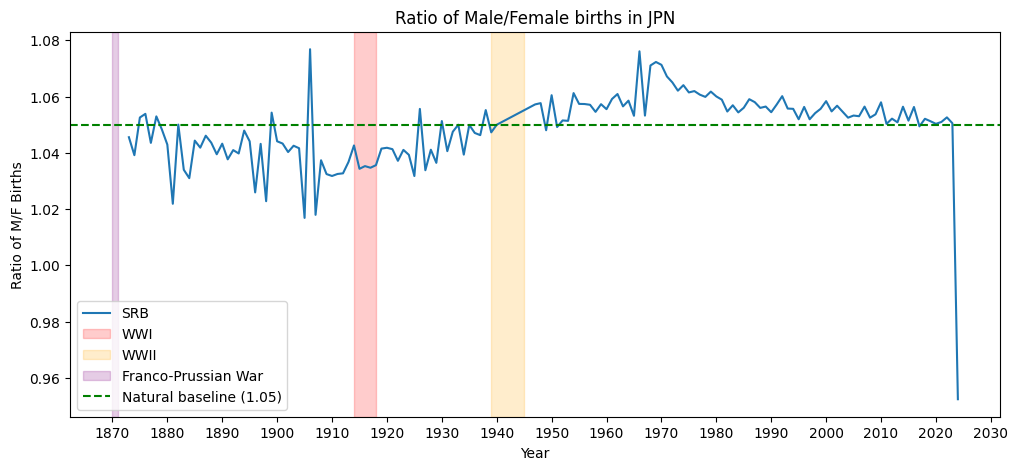

RUS


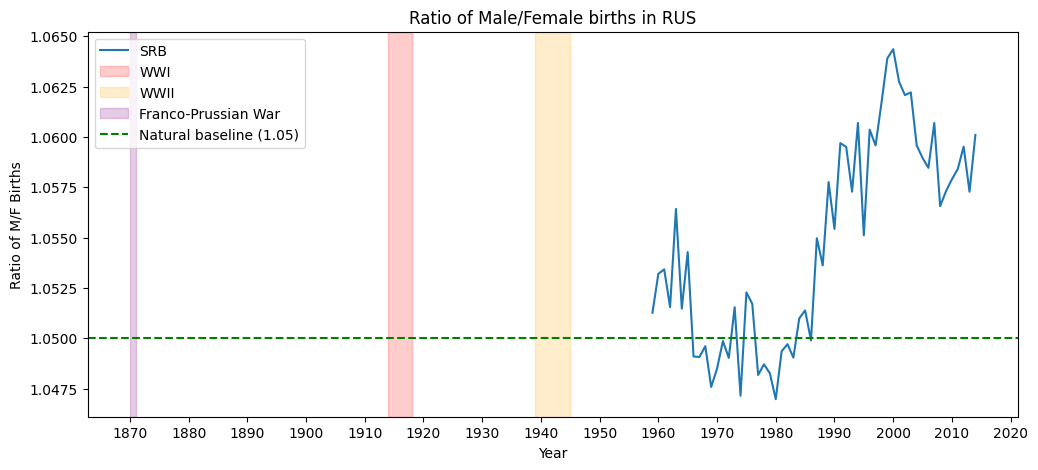

USA


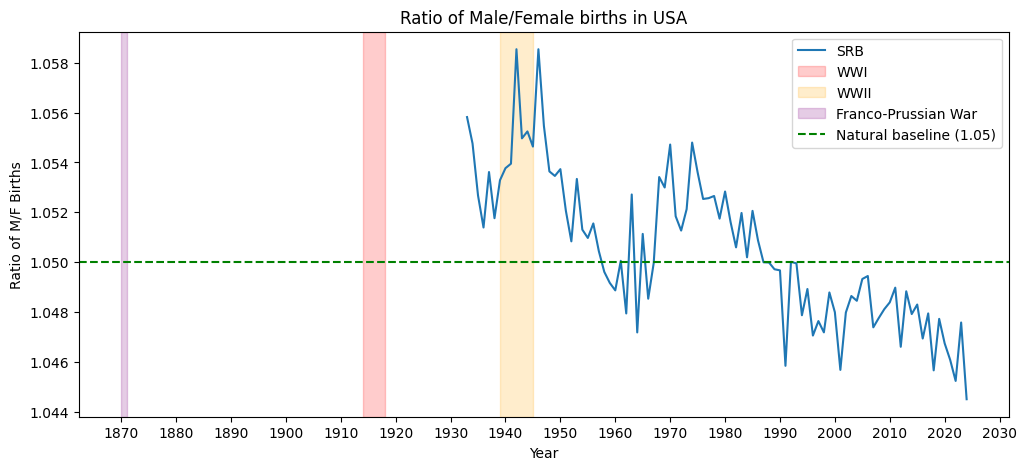

In [75]:
country_codes = hmd_births_clean["PopName"].unique()
for i in country_codes:
    print(i)
    srb_country = calculate_srb(hmd_births_clean, i)
    fig, ax = plt.subplots(figsize=(12,5))
    #sex_labels = {'f': 'Female', 'm': 'Male'}
    ax.plot(srb_country.index, srb_country["SRB"], label="SRB")  
    ax.set_title(f"Ratio of Male/Female births in {i}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Ratio of M/F Births")
    ax.set_xticks(range(1830, 2040, 10))
    ax.axvspan(1914, 1918, alpha=0.2, color='red', label='WWI')
    ax.axvspan(1939, 1945, alpha=0.2, color='orange', label='WWII')
    ax.axvspan(1870, 1871, alpha=0.2, color='purple', label='Franco-Prussian War')
    ax.axhline(1.05, color='green', linestyle='--', label='Natural baseline (1.05)')
    ax.legend()
    plt.show()